--> Using device: cuda
--> Initializing and loading MNIST...


100%|██████████| 9.91M/9.91M [00:00<00:00, 17.6MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 456kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.23MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 9.41MB/s]


--> Training FP32 Model (1 Epoch)...
Batch 0, Loss: 2.3195
Batch 100, Loss: 0.2215
Batch 200, Loss: 0.0556

 PROFILING ACTIVATIONS & WEIGHTS ON FULL TEST SET (10,000 images)
Conv1 (Before ReLU)  | Min:  -4.3415 | Max:   3.2805 | Mean:   0.0225 | Std:   0.6403
ReLU1 (After ReLU)   | Min:   0.0000 | Max:   3.2805 | Mean:   0.1893 | Std:   0.3853
Pool1 (After Pool)   | Min:   0.0000 | Max:   3.2805 | Mean:   0.2965 | Std:   0.4840
FC Output (Logits)   | Min: -23.3878 | Max:  16.3083 | Mean:  -3.0879 | Std:   5.2850
---------------------------------------------------------------------------
Conv1 Weights        | Min:  -0.6690 | Max:   0.6081 | Mean:   0.0050 | Std:   0.2572
FC Weights           | Min:  -0.7335 | Max:   0.5414 | Mean:  -0.0237 | Std:   0.1284


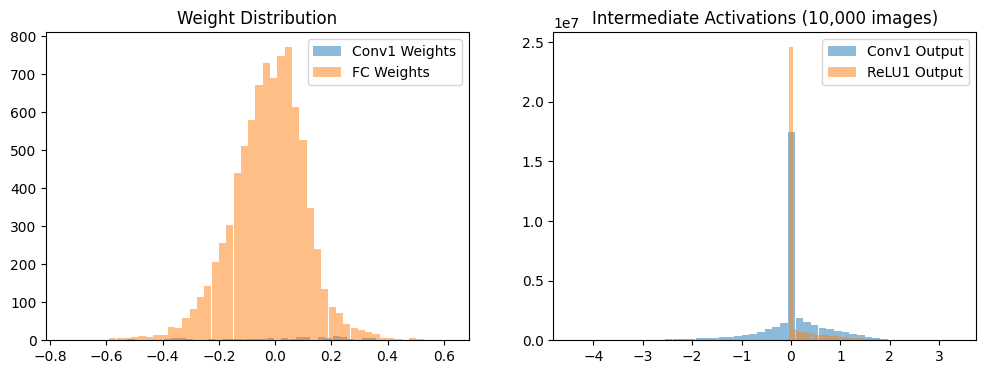


--> Selecting Q3.12 Format.
Scale factor: 4096

--> Verifying Accuracy: FP32 vs Pure Integer Datapath on GPU...
FP32 Accuracy:  96.87%
INT16 Accuracy: 96.86% (Static Truncation Simulated)


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

# Check for GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"--> Using device: {device}")

# ==========================================
# STEP 1: Define FP32 Model & Train
# ==========================================
class SimpleRTLCNN(nn.Module):
    def __init__(self):
        super(SimpleRTLCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 6, kernel_size=5, bias=False)
        self.fc = nn.Linear(6 * 12 * 12, 10, bias=False)

    def forward(self, x):
        c1 = self.conv1(x)
        r1 = F.relu(c1)
        p1 = F.max_pool2d(r1, 2)

        flat = p1.view(p1.size(0), -1)
        out = self.fc(flat)

        return out, c1, r1, p1

print("--> Initializing and loading MNIST...")
transform = transforms.Compose([transforms.ToTensor()])
trainset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=256, shuffle=True)

testset = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=1000, shuffle=False)

model = SimpleRTLCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.005)

print("--> Training FP32 Model (1 Epoch)...")
model.train()
for i, (images, labels) in enumerate(trainloader):
    images, labels = images.to(device), labels.to(device)
    optimizer.zero_grad()
    outputs, _, _, _ = model(images)
    loss = criterion(outputs, labels)
    loss.backward()
    optimizer.step()
    if i % 100 == 0:
        print(f"Batch {i}, Loss: {loss.item():.4f}")

# ==========================================
# STEP 2: Profile Weights & Activations (Full 10k Images)
# ==========================================
print("\n" + "="*75)
print(" PROFILING ACTIVATIONS & WEIGHTS ON FULL TEST SET (10,000 images)")
print("="*75)
model.eval()

c1_list, r1_list, p1_list, out_list = [], [], [], []

with torch.no_grad():
    for images, _ in testloader:
        images = images.to(device)
        out, c1, r1, p1 = model(images)
        c1_list.append(c1)
        r1_list.append(r1)
        p1_list.append(p1)
        out_list.append(out)

# Concatenate on GPU
c1_all  = torch.cat(c1_list, dim=0)
r1_all  = torch.cat(r1_list, dim=0)
p1_all  = torch.cat(p1_list, dim=0)
out_all = torch.cat(out_list, dim=0)

def print_stats(name, tensor):
    print(f"{name:20s} | Min: {tensor.min().item():8.4f} | Max: {tensor.max().item():8.4f} | Mean: {tensor.mean().item():8.4f} | Std: {tensor.std().item():8.4f}")

print_stats("Conv1 (Before ReLU)", c1_all)
print_stats("ReLU1 (After ReLU)", r1_all)
print_stats("Pool1 (After Pool)", p1_all)
print_stats("FC Output (Logits)", out_all)
print("-" * 75)
print_stats("Conv1 Weights", model.conv1.weight)
print_stats("FC Weights", model.fc.weight)
print("="*75)

# Fast GPU-based histogram plotting
def plot_gpu_hist(tensor, bins=50, alpha=0.5, label=''):
    t_min, t_max = tensor.min().item(), tensor.max().item()
    hist = torch.histc(tensor, bins=bins, min=t_min, max=t_max)
    x = torch.linspace(t_min, t_max, steps=bins)
    plt.bar(x.cpu().numpy(), hist.cpu().numpy(), width=(t_max-t_min)/bins, alpha=alpha, label=label)

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plot_gpu_hist(model.conv1.weight, label='Conv1 Weights')
plot_gpu_hist(model.fc.weight, label='FC Weights')
plt.title("Weight Distribution")
plt.legend()

plt.subplot(1, 2, 2)
plot_gpu_hist(c1_all, label='Conv1 Output')
plot_gpu_hist(r1_all, label='ReLU1 Output')
plt.title("Intermediate Activations (10,000 images)")
plt.legend()
plt.show()

# ==========================================
# STEP 3: Decide Qm.n Format
# ==========================================
# Defaulting to Q4.12. Check your console logs for Max 'FC Output'.
# If Max > 7.99, you must decrease FRAC_BITS to 11.
FRAC_BITS = 12
SCALE = 2 ** FRAC_BITS

print(f"\n--> Selecting Q{15-FRAC_BITS}.{FRAC_BITS} Format.")
print(f"Scale factor: {SCALE}")

# ==========================================
# STEP 4: Convert Weights to Integer (Keep on GPU)
# ==========================================
def quantize_tensor(tensor, scale):
    q_tensor = torch.round(tensor * scale)
    return torch.clamp(q_tensor, min=-32768, max=32767).to(torch.int16)

w_conv1_int = quantize_tensor(model.conv1.weight.data, SCALE).to(device)
w_fc_int = quantize_tensor(model.fc.weight.data, SCALE).to(device)

# ==========================================
# STEP 5: Bit-Accurate Integer Forward Pass (GPU Accelerated)
# ==========================================
def int16_mac_and_truncate(input_int, weight_int, is_linear=False):
    inp_f = input_int.to(torch.float32)
    w_f = weight_int.to(torch.float32)

    if is_linear:
        mac_32bit = F.linear(inp_f, w_f)
    else:
        mac_32bit = F.conv2d(inp_f, w_f)

    truncated = torch.floor(mac_32bit / SCALE)
    return torch.clamp(truncated, min=-32768, max=32767).to(torch.int16)

def hardware_forward_pass(image_float):
    x = quantize_tensor(image_float, SCALE)

    x = int16_mac_and_truncate(x, w_conv1_int)
    x = F.relu(x)
    x = F.max_pool2d(x.to(torch.float32), 2).to(torch.int16)

    x = x.view(x.size(0), -1)
    out = int16_mac_and_truncate(x, w_fc_int, is_linear=True)

    return out

# --- Verification ---
print("\n--> Verifying Accuracy: FP32 vs Pure Integer Datapath on GPU...")
correct_fp32 = 0
correct_int16 = 0
total = 0

model.eval()
with torch.no_grad():
    for images, labels in testloader:
        images, labels = images.to(device), labels.to(device)

        # 1. Original Float Model Prediction
        out_fp32, _, _, _ = model(images)
        _, pred_fp32 = torch.max(out_fp32.data, 1)
        correct_fp32 += (pred_fp32 == labels).sum().item()

        # 2. Simulated RTL Integer Prediction
        out_int16 = hardware_forward_pass(images)
        _, pred_int16 = torch.max(out_int16.data, 1)
        correct_int16 += (pred_int16 == labels).sum().item()

        total += labels.size(0)

print(f"FP32 Accuracy:  {100 * correct_fp32 / total:.2f}%")
print(f"INT16 Accuracy: {100 * correct_int16 / total:.2f}% (Static Truncation Simulated)")

--> Using device: cuda

--> Training FP32 Model for 10 Epochs...
Epoch [ 1/10] | Train Loss: 0.3138 | Val Loss: 0.1389
Epoch [ 2/10] | Train Loss: 0.1246 | Val Loss: 0.0942
Epoch [ 3/10] | Train Loss: 0.0934 | Val Loss: 0.0780
Epoch [ 4/10] | Train Loss: 0.0776 | Val Loss: 0.0653
Epoch [ 5/10] | Train Loss: 0.0684 | Val Loss: 0.0651
Epoch [ 6/10] | Train Loss: 0.0588 | Val Loss: 0.0622
Epoch [ 7/10] | Train Loss: 0.0536 | Val Loss: 0.0604
Epoch [ 8/10] | Train Loss: 0.0500 | Val Loss: 0.0622
Epoch [ 9/10] | Train Loss: 0.0446 | Val Loss: 0.0615
Epoch [10/10] | Train Loss: 0.0410 | Val Loss: 0.0549


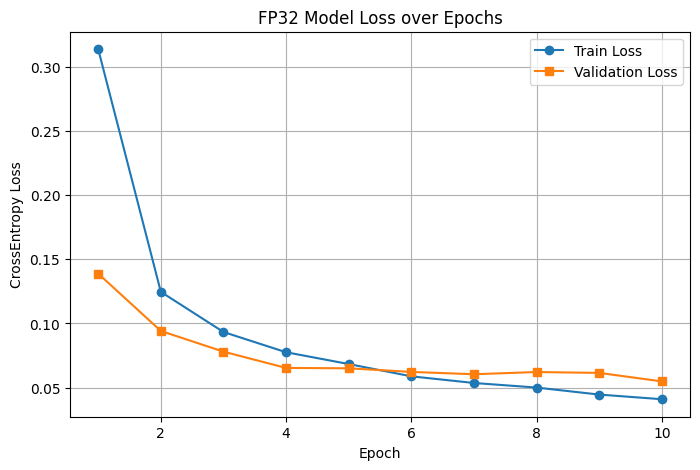


--> Converting weights and operations to Q1.5.10 (Scale: 1024)...

--> Evaluating FP32 vs Q1.5.10 on Validation Set...

 FINAL COMPARISON (Validation Set: 10,000 images)
FP32 Model     | Loss: 0.0549 | Accuracy: 98.31%
Q1.5.10 Model  | Loss: 0.0549 | Accuracy: 98.32%


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

# Device configuration (Utilizing your Colab T4 GPU)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"--> Using device: {device}")

# ==========================================
# 1. Define FP32 Model & Load Data
# ==========================================
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        # Input: 1x28x28 -> Conv: 6x24x24 -> MaxPool: 6x12x12
        self.conv1 = nn.Conv2d(1, 6, kernel_size=5, bias=False)
        self.fc = nn.Linear(6 * 12 * 12, 10, bias=False)

    def forward(self, x):
        x = self.conv1(x)
        x = F.relu(x)
        x = F.max_pool2d(x, 2)

        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x

transform = transforms.Compose([transforms.ToTensor()])
trainset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=256, shuffle=True)

valset = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)
valloader = torch.utils.data.DataLoader(valset, batch_size=1000, shuffle=False)

model = SimpleCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.005)

# ==========================================
# 2. Train for 10 Epochs & Plot Losses
# ==========================================
epochs = 10
train_losses = []
val_losses = []

print(f"\n--> Training FP32 Model for {epochs} Epochs...")
for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    for images, labels in trainloader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

    epoch_train_loss = running_loss / len(trainloader.dataset)
    train_losses.append(epoch_train_loss)

    # Validation Phase
    model.eval()
    running_val_loss = 0.0
    with torch.no_grad():
        for images, labels in valloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            running_val_loss += loss.item() * images.size(0)

    epoch_val_loss = running_val_loss / len(valloader.dataset)
    val_losses.append(epoch_val_loss)

    print(f"Epoch [{epoch+1:2d}/{epochs}] | Train Loss: {epoch_train_loss:.4f} | Val Loss: {epoch_val_loss:.4f}")


plt.figure(figsize=(8, 5))
plt.plot(range(1, epochs+1), train_losses, label='Train Loss', marker='o')
plt.plot(range(1, epochs+1), val_losses, label='Validation Loss', marker='s')
plt.title('FP32 Model Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('CrossEntropy Loss')
plt.legend()
plt.grid(True)
plt.show()

# ==========================================
# 3. Convert to Q1.5.10 Format & Build Hardware Datapath
# ==========================================
FRAC_BITS = 10
SCALE = 2 ** FRAC_BITS  # 1024

print(f"\n--> Converting weights and operations to Q1.5.10 (Scale: {SCALE})...")

def quantize_tensor(tensor):
    """Scales, rounds to nearest integer, and clamps to 16-bit limits."""
    q_tensor = torch.round(tensor * SCALE)
    return torch.clamp(q_tensor, min=-32768, max=32767).to(torch.int16)

# Extract and freeze weights in Q1.5.10 format
model.eval()
w_conv1_q = quantize_tensor(model.conv1.weight.data).to(device)
w_fc_q = quantize_tensor(model.fc.weight.data).to(device)

def q1_5_10_mac_truncate(input_q, weight_q, is_linear=False):
    """
    Simulates the RTL hardware datapath:
    16-bit inputs -> 32-bit MAC -> Truncate lowest 10 bits -> Clamp to 16-bit
    """
    inp_f = input_q.to(torch.float32)
    w_f = weight_q.to(torch.float32)

    # 1. Multiplication and Addition (Accumulator)
    if is_linear:
        mac_32 = F.linear(inp_f, w_f)
    else:
        mac_32 = F.conv2d(inp_f, w_f)

    # 2. Wire truncation: Shift right by FRAC_BITS (Discarding lowest 10 bits)
    truncated = torch.floor(mac_32 / SCALE)

    # 3. Clamping limits (Hardware Saturation)
    return torch.clamp(truncated, min=-32768, max=32767).to(torch.int16)

def quantized_forward(images_float):
    # Quantize the input image
    x_q = quantize_tensor(images_float)

    # Layer 1: Conv -> ReLU -> MaxPool
    x_q = q1_5_10_mac_truncate(x_q, w_conv1_q)
    x_q = F.relu(x_q) # Integer ReLU acts exactly like float
    x_q = F.max_pool2d(x_q.to(torch.float32), 2).to(torch.int16) # Pooling logic

    # Layer 2: Flatten -> Fully Connected
    x_q = x_q.view(x_q.size(0), -1)
    out_q = q1_5_10_mac_truncate(x_q, w_fc_q, is_linear=True)

    return out_q

# ==========================================
# 4. Compare FP32 vs Q1.5.10 Validation Loss
# ==========================================
print("\n--> Evaluating FP32 vs Q1.5.10 on Validation Set...")

fp32_correct, q_correct = 0, 0
fp32_loss_total, q_loss_total = 0.0, 0.0
total_samples = 0

with torch.no_grad():
    for images, labels in valloader:
        images, labels = images.to(device), labels.to(device)
        total_samples += labels.size(0)

        # --- FP32 Inference ---
        out_fp32 = model(images)
        loss_fp32 = criterion(out_fp32, labels)
        fp32_loss_total += loss_fp32.item() * labels.size(0)
        _, pred_fp32 = torch.max(out_fp32, 1)
        fp32_correct += (pred_fp32 == labels).sum().item()

        # --- Q1.5.10 Inference ---
        out_q = quantized_forward(images)

        # To compute a comparable mathematical loss, we must rescale the integer
        # logits back to the floating point range before passing to CrossEntropy
        out_q_float = out_q.to(torch.float32) / SCALE
        loss_q = criterion(out_q_float, labels)
        q_loss_total += loss_q.item() * labels.size(0)

        # Accuracy doesn't require rescaling, argmax works natively on integers
        _, pred_q = torch.max(out_q, 1)
        q_correct += (pred_q == labels).sum().item()

# Compute final averages
final_fp32_loss = fp32_loss_total / total_samples
final_fp32_acc = 100.0 * fp32_correct / total_samples

final_q_loss = q_loss_total / total_samples
final_q_acc = 100.0 * q_correct / total_samples

print("\n" + "="*55)
print(" FINAL COMPARISON (Validation Set: 10,000 images)")
print("="*55)
print(f"FP32 Model     | Loss: {final_fp32_loss:.4f} | Accuracy: {final_fp32_acc:.2f}%")
print(f"Q1.5.10 Model  | Loss: {final_q_loss:.4f} | Accuracy: {final_q_acc:.2f}%")
print("="*55)

In [ ]:
def zeros_1d(D1):
    return [0.0 for _ in range(D1)]

def zeros_2d(D1, D2):
    return [[0.0 for _ in range(D2)] for _ in range(D1)]

def zeros_3d(D1, D2, D3):
    return [[[0.0 for _ in range(D3)] for _ in range(D2)] for _ in range(D1)]

def zeros_4d(D1, D2, D3, D4):
    return [[[[0.0 for _ in range(D4)] for _ in range(D3)] for _ in range(D2)] for _ in range(D1)]

def run_dataflow_analysis(scheme):
    # --- Network Dimensions ---
    C_in, H_in, W_in = 1, 28, 28
    K, C_out, R, S = 6, 1, 5, 5
    H_out, W_out = 24, 24
    H_pool, W_pool = 12, 12
    FC_in, FC_out = 864, 10

    # --- Initialize "Memory" ---
    image = zeros_3d(C_in, H_in, W_in)
    conv_w = zeros_4d(K, C_in, R, S)
    conv_out = zeros_3d(K, H_out, W_out)
    relu_out = zeros_3d(K, H_out, W_out)
    pool_out = zeros_3d(K, H_pool, W_pool)
    fc_w = zeros_2d(FC_out, FC_in)
    fc_out_arr = zeros_1d(FC_out)

    # --- Trackers ---
    reads = 0
    writes = 0
    muls = 0
    adds = 0

    # ==========================================
    # 1. CONVOLUTION LAYER
    # ==========================================
    if scheme == "OS":
        # OUTPUT STATIONARY
        # Keep accumulator in local register, loop over weights and inputs
        for k in range(K):
            for y in range(H_out):
                for x in range(W_out):
                    acc = 0.0 # Local register
                    for c in range(C_in):
                        for r in range(R):
                            for s in range(S):
                                w = conv_w[k][c][r][s]
                                i = image[c][y+r][x+s]
                                reads += 2
                                acc += w * i
                                muls += 1; adds += 1
                    conv_out[k][y][x] = acc
                    writes += 1

    elif scheme == "WS":
        # WEIGHT STATIONARY
        # Keep weight in local register, loop over inputs and outputs
        writes += K * H_out * W_out # Cost to initialize memory with zeros
        for k in range(K):
            for c in range(C_in):
                for r in range(R):
                    for s in range(S):
                        w = conv_w[k][c][r][s] # Local register
                        reads += 1
                        for y in range(H_out):
                            for x in range(W_out):
                                i = image[c][y+r][x+s]
                                o = conv_out[k][y][x]
                                reads += 2
                                o += w * i
                                muls += 1; adds += 1
                                conv_out[k][y][x] = o
                                writes += 1

    elif scheme == "IS":
        # INPUT STATIONARY
        # Keep input pixel in local register, loop over weights and outputs
        writes += K * H_out * W_out # Cost to initialize memory with zeros
        for c in range(C_in):
            for y_in in range(H_in):
                for x_in in range(W_in):
                    in_val = image[c][y_in][x_in] # Local register
                    reads += 1
                    for k in range(K):
                        for r in range(R):
                            for s in range(S):
                                y_out = y_in - r
                                x_out = x_in - s
                                # Only process if the input contributes to a valid output pixel
                                if 0 <= y_out < H_out and 0 <= x_out < W_out:
                                    w = conv_w[k][c][r][s]
                                    o = conv_out[k][y_out][x_out]
                                    reads += 2
                                    o += w * in_val
                                    muls += 1; adds += 1
                                    conv_out[k][y_out][x_out] = o
                                    writes += 1

    # ==========================================
    # 2. ReLU LAYER (Pointwise)
    # ==========================================
    for k in range(K):
        for y in range(H_out):
            for x in range(W_out):
                val = conv_out[k][y][x]
                reads += 1
                if val > 0:
                    relu_out[k][y][x] = val
                else:
                    relu_out[k][y][x] = 0.0
                writes += 1

    # ==========================================
    # 3. MAX POOL LAYER (2x2)
    # ==========================================
    for k in range(K):
        for y in range(H_pool):
            for x in range(W_pool):
                max_val = -float('inf')
                for py in range(2):
                    for px in range(2):
                        val = relu_out[k][y*2+py][x*2+px]
                        reads += 1
                        if val > max_val:
                            max_val = val
                pool_out[k][y][x] = max_val
                writes += 1

    # ==========================================
    # 4. FULLY CONNECTED LAYER
    # ==========================================
    # Flattening logic mapped directly via indexing: fc_in_idx = k*144 + y*12 + x
    if scheme == "OS":
        for out_idx in range(FC_out):
            acc = 0.0
            for in_idx in range(FC_in):
                k = in_idx // 144
                rem = in_idx % 144
                y = rem // 12
                x = rem % 12

                w = fc_w[out_idx][in_idx]
                i = pool_out[k][y][x]
                reads += 2
                acc += w * i
                muls += 1; adds += 1
            fc_out_arr[out_idx] = acc
            writes += 1

    elif scheme == "WS":
        writes += FC_out
        for out_idx in range(FC_out):
            for in_idx in range(FC_in):
                k = in_idx // 144
                rem = in_idx % 144
                y = rem // 12
                x = rem % 12

                w = fc_w[out_idx][in_idx]
                reads += 1

                i = pool_out[k][y][x]
                o = fc_out_arr[out_idx]
                reads += 2
                o += w * i
                muls += 1; adds += 1
                fc_out_arr[out_idx] = o
                writes += 1

    elif scheme == "IS":
        writes += FC_out
        for in_idx in range(FC_in):
            k = in_idx // 144
            rem = in_idx % 144
            y = rem // 12
            x = rem % 12

            i = pool_out[k][y][x]
            reads += 1
            for out_idx in range(FC_out):
                w = fc_w[out_idx][in_idx]
                o = fc_out_arr[out_idx]
                reads += 2
                o += w * i
                muls += 1; adds += 1
                fc_out_arr[out_idx] = o
                writes += 1

    return reads, writes, muls, adds

# --- Run and Format Output ---
print(f"{'Scheme':<6} | {'Mem Reads':<12} | {'Mem Writes':<12} | {'Multiplies':<12} | {'Additions':<12}")
print("-" * 65)
for s in ["OS", "WS", "IS"]:
    r, w, m, a = run_dataflow_analysis(s)
    print(f"{s:<6} | {r:<12,} | {w:<12,} | {m:<12,} | {a:<12,}")

Scheme | Mem Reads    | Mem Writes   | Multiplies   | Additions   
-----------------------------------------------------------------
OS     | 196,992      | 7,786        | 95,040       | 95,040      
WS     | 205,782      | 102,826      | 95,040       | 95,040      
IS     | 198,640      | 102,826      | 95,040       | 95,040      


In [ ]:
import math

def analyze_pe_array_dimensions(PE_ROWS, PE_COLS):
    # --- Network Dimensions (Conv1) ---
    C_in, H_in, W_in = 1, 28, 28
    K, C_out, R, S = 6, 1, 5, 5
    H_out, W_out = 24, 24

    # Flattened inner product size per output pixel
    inner_product_size = C_in * R * S  # 1 * 5 * 5 = 25

    # Total output pixels
    out_pixels = H_out * W_out  # 24 * 24 = 576

    # --- Hardware Arrays & Counters ---
    global_reads = 0   # BRAM reads
    global_writes = 0  # BRAM writes
    pe_local_reads = 0 # Register reads inside PEs
    pe_local_writes = 0 # Register writes inside PEs
    active_macs = 0
    idle_macs = 0      # Measures array utilization

    print(f"--- Simulating {PE_ROWS}x{PE_COLS} Weight Stationary Array ---")

    # Calculate how many tiles we need to cover the entire layer
    # Tile across the inner product dimension (Rows)
    row_tiles = math.ceil(inner_product_size / PE_ROWS)
    # Tile across the output channels (Columns)
    col_tiles = math.ceil(K / PE_COLS)

    for c_tile in range(col_tiles):
        for r_tile in range(row_tiles):
            # 1. LOAD WEIGHTS PHASE
            # Fetch weights from BRAM and load them into the stationary PE registers
            active_cols = min(PE_COLS, K - c_tile * PE_COLS)
            active_rows = min(PE_ROWS, inner_product_size - r_tile * PE_ROWS)

            global_reads += active_rows * active_cols
            pe_local_writes += active_rows * active_cols

            # 2. STREAM INPUTS & COMPUTE PHASE
            # For each spatial pixel, stream inputs across rows and accumulate down columns
            for pixel in range(out_pixels):
                # Fetch inputs from Global Buffer (Line Buffer) to feed the left edge of the array
                global_reads += active_rows

                # Each active PE reads its stationary weight, reads the flowing input,
                # multiplies, and adds to the flowing partial sum.
                pe_local_reads += (active_rows * active_cols) * 2 # Read weight + read input
                active_macs += active_rows * active_cols
                idle_macs += (PE_ROWS * PE_COLS) - (active_rows * active_cols)

                # 3. DRAIN PARTIAL SUMS PHASE
                # The bottom edge of the array pushes partial sums out
                if r_tile == row_tiles - 1:
                    # Final tile: write the finished accumulator to Global BRAM
                    global_writes += active_cols
                else:
                    # Intermediate tile: write partial sum back to BRAM to be re-loaded later
                    # (A perfectly sized array avoids this entirely!)
                    global_writes += active_cols
                    global_reads += active_cols # Cost to re-read it for the next row_tile

    # --- Print Metrics ---
    total_macs = active_macs + idle_macs
    utilization = (active_macs / total_macs) * 100 if total_macs > 0 else 0

    print(f"Array Utilization : {utilization:.1f}%")
    print(f"Global BRAM Reads : {global_reads:,}")
    print(f"Global BRAM Writes: {global_writes:,}")
    print(f"PE Register Reads : {pe_local_reads:,}")
    print(f"PE Register Writes: {pe_local_writes:,}\n")


# Let's test a few arbitrary sizes to see how the memory hierarchy reacts
analyze_pe_array_dimensions(PE_ROWS=5, PE_COLS=6)
analyze_pe_array_dimensions(PE_ROWS=25, PE_COLS=6)

--- Simulating 5x6 Weight Stationary Array ---
Array Utilization : 100.0%
Global BRAM Reads : 28,374
Global BRAM Writes: 17,280
PE Register Reads : 172,800
PE Register Writes: 150

--- Simulating 25x6 Weight Stationary Array ---
Array Utilization : 100.0%
Global BRAM Reads : 14,550
Global BRAM Writes: 3,456
PE Register Reads : 172,800
PE Register Writes: 150

